# Figure 4: IR Brightness Temperature Film Strip (4×4 panel)

**Preferred source**: GridSat-B1 `irwin_cdr` → quantitative `pcolormesh` with shared colourbar (K).  
**Fallback**: GIBS IR PNG tile where GridSat file is absent.

Cyan contour = 235 K CDO boundary (SW-dimming footprint).  
**Rows** = storms | **Cols** = T−48 h, T_peak, T_closest, T+24 h  

**Prerequisites**: `data/gridsat/{storm}/` (run `03_download_gridsat.py`), `data/gibs/{storm}/ir_*.png` (run `04_download_gibs.py`).

## 1: Setup

In [4]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from PIL import Image

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import (GRIDSAT_DIR, GIBS_DIR, IBTRACS_DIR, FIG_DIR,
                   STORM_ORDER, STORMS, BT_COLD, BT_CDO, ensure_dirs)

ensure_dirs()
OUTPATH    = os.path.join(FIG_DIR, 'ir_filmstrip.png')
COL_LABELS = ['T−48 h', 'T_peak', 'T_closest\n(impact ref)', 'T+24 h']
DATE_KEYS  = ['t_minus48_date', 't_peak_date', 't_closest_date', 't_plus24_date']
LABEL_TAGS = ['T-48h', 'T_peak', 'T_closest', 'T+24h']
BT_VMIN, BT_VMAX = 190, 300
BT_CMAP = 'gray_r'   # cold tops = dark (conventional IR display)

## 2: Helper functions

In [5]:
def gridsat_nc_for_date(key, date_str):
    """Return GridSat file path for a given date (noon UTC preferred)."""
    nc_dir = os.path.join(GRIDSAT_DIR, key)
    if not os.path.isdir(nc_dir):
        return None
    date_nd = date_str.replace('-', '.')
    for h in ['12', '09', '15', '06', '18', '03', '21', '00']:
        p = os.path.join(nc_dir, f'GRIDSAT-B1.{date_nd}.{h}.nc')
        if os.path.exists(p):
            return p
    return None


def storm_center_at_date(track_df, date_str):
    target = pd.Timestamp(date_str)
    diffs  = (track_df['ISO_TIME'] - target).abs()
    idx    = diffs.idxmin()
    return float(track_df.loc[idx, 'LAT']), float(track_df.loc[idx, 'LON'])


def plot_gridsat_panel(ax, nc_path, lat_c, lon_c, delta=8.0):
    ds     = xr.open_dataset(nc_path, engine='netcdf4')
    bt_da  = ds['irwin_cdr'].squeeze()
    subset = bt_da.sel(lat=slice(lat_c - delta, lat_c + delta),
                       lon=slice(lon_c - delta, lon_c + delta))
    bt     = subset.values
    lats   = subset.lat.values
    lons   = subset.lon.values
    ds.close()

    if bt.size == 0 or not np.isfinite(bt).any():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, color='0.5')
        return

    LON2D, LAT2D = np.meshgrid(lons, lats)
    ax.pcolormesh(LON2D, LAT2D, bt, cmap=BT_CMAP,
                  vmin=BT_VMIN, vmax=BT_VMAX, shading='nearest')
    if (bt < BT_CDO).any():
        ax.contour(LON2D, LAT2D, bt, levels=[BT_CDO],
                   colors=['cyan'], linewidths=0.7, linestyles='--')
    ax.axhline(lat_c, color='yellow', linewidth=0.5, alpha=0.6)
    ax.axvline(lon_c, color='yellow', linewidth=0.5, alpha=0.6)
    ax.set_xlim(lon_c - delta, lon_c + delta)
    ax.set_ylim(lat_c - delta, lat_c + delta)


def plot_gibs_panel(ax, key, label_tag, date_str):
    matches = glob.glob(os.path.join(GIBS_DIR, key, f'ir_{label_tag}_{date_str}.png'))
    if not matches:
        matches = glob.glob(os.path.join(GIBS_DIR, key, f'ir_{label_tag}_*.png'))
    if not matches:
        ax.set_facecolor('0.2')
        ax.text(0.5, 0.5, 'IR unavailable', ha='center', va='center',
                transform=ax.transAxes, color='white', fontsize=8)
        ax.axis('off')
        return
    try:
        ax.imshow(np.array(Image.open(matches[0]).convert('RGB')))
    except Exception:
        ax.set_facecolor('0.2')
    ax.axis('off')


print('Helpers defined.')

Helpers defined.


## 3: Assemble and save

/tmp/ipykernel_24057/3187425047.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


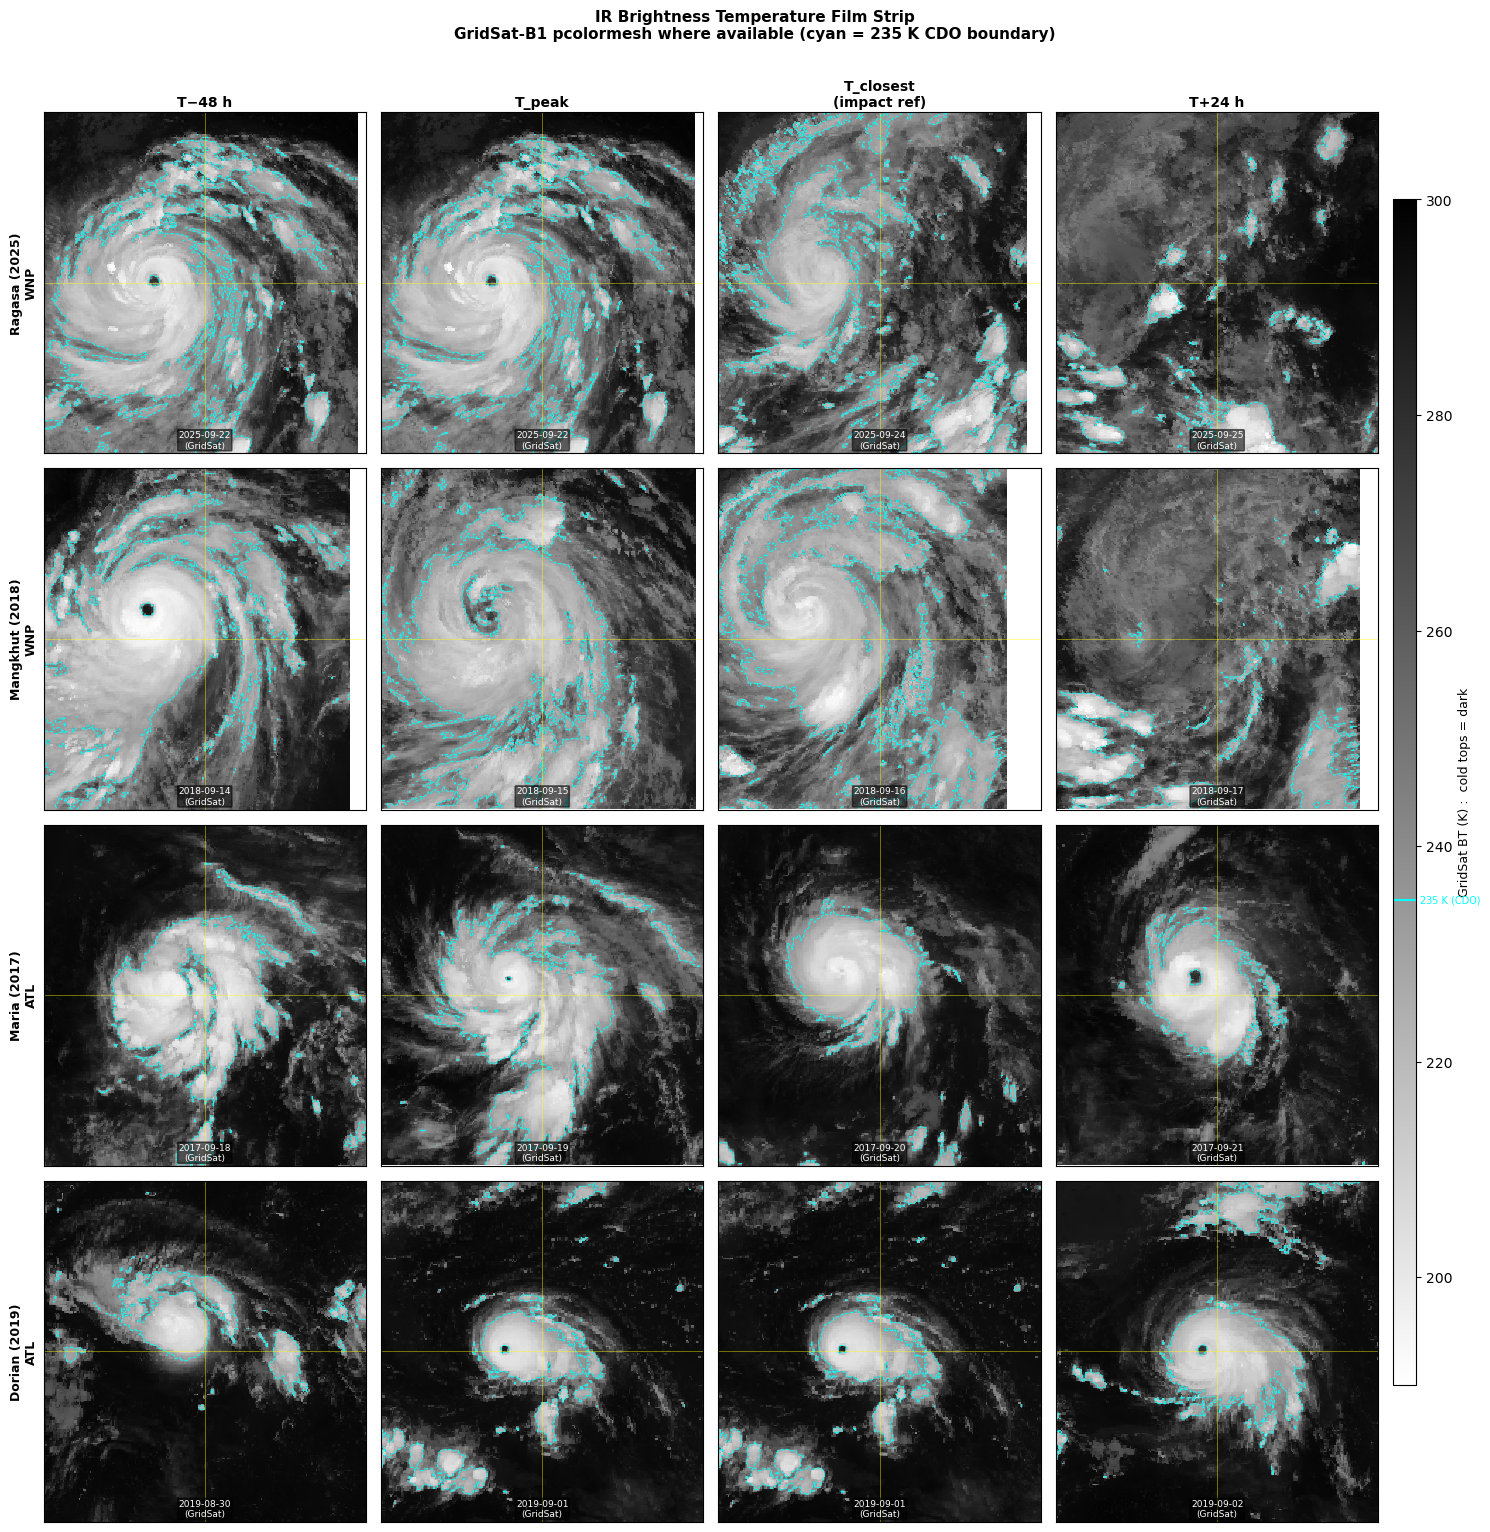

Saved → /home/sharperace/geog_1.02_final_proj/figures/ir_filmstrip.png


In [6]:
n_rows, n_cols = len(STORM_ORDER), len(COL_LABELS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.8, n_rows * 3.8))

for r, key in enumerate(STORM_ORDER):
    meta      = STORMS[key]
    track_csv = os.path.join(IBTRACS_DIR, f'{key}_track.csv')
    track_df  = (pd.read_csv(track_csv, parse_dates=['ISO_TIME'])
                 if os.path.exists(track_csv) else None)

    for c, (label_tag, date_key, col_lbl) in enumerate(
            zip(LABEL_TAGS, DATE_KEYS, COL_LABELS)):

        ax       = axes[r][c]
        date_str = meta[date_key]

        nc_path = gridsat_nc_for_date(key, date_str)
        if nc_path and track_df is not None:
            lat_c, lon_c = storm_center_at_date(track_df, date_str)
            try:
                plot_gridsat_panel(ax, nc_path, lat_c, lon_c)
                source = 'GridSat'
            except Exception as exc:
                print(f'  GridSat panel failed ({key} {date_str}): {exc}')
                plot_gibs_panel(ax, key, label_tag, date_str)
                source = 'GIBS'
        else:
            plot_gibs_panel(ax, key, label_tag, date_str)
            source = 'GIBS'

        ax.set_xticks([])
        ax.set_yticks([])

        if r == 0:
            ax.set_title(col_lbl, fontsize=10, fontweight='bold', pad=4)

        ax.text(0.5, 0.01, f'{date_str}\n({source})',
                transform=ax.transAxes, ha='center', va='bottom',
                fontsize=6.5, color='white',
                bbox=dict(boxstyle='round,pad=0.1', fc='k', alpha=0.55))

    axes[r][0].set_ylabel(
        f"{meta['name']} ({meta['year']})\n{meta['basin']}",
        fontsize=9, fontweight='bold', rotation=90, labelpad=4
    )

# Shared BT colourbar
sm  = plt.cm.ScalarMappable(cmap=BT_CMAP,
                              norm=mcolors.Normalize(BT_VMIN, BT_VMAX))
sm.set_array([])
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78])
cb  = fig.colorbar(sm, cax=cax)
cb.set_label('GridSat BT (K) :  cold tops = dark', fontsize=9)
cb.ax.axhline(BT_CDO, color='cyan', linewidth=1.5)
cb.ax.text(1.15, BT_CDO, f'{BT_CDO} K (CDO)', transform=cb.ax.transData,
           va='center', fontsize=7, color='cyan')

fig.suptitle(
    'IR Brightness Temperature Film Strip\n'
    'GridSat-B1 pcolormesh where available (cyan = 235 K CDO boundary)',
    fontsize=11, fontweight='bold', y=1.005
)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig(OUTPATH, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPATH}')